<a href="https://colab.research.google.com/github/sindetisarah/DataScience_fundamentals/blob/feature%2Fdatascience_fundamentals/SarahSindet_Predict_Price_Of_Gold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#TASK IS TO PREDICT THE PRICE OF GOLD
#make the necessarry imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

In [ ]:
#fetch dataset
gold_dataset = pd.read_csv('/content/indexData.csv')
gold_dataset

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.0
...,...,...,...,...,...,...,...,...
39627,000001.SS,2014-04-30,2020.437988,2029.537964,2016.577026,2026.358032,2026.358032,74500.0
39628,000001.SS,2014-05-05,2022.177979,2028.957031,2007.350952,2027.353027,2027.353027,79900.0
39629,000001.SS,2014-05-06,2024.255981,2038.704956,2021.484985,2028.037964,2028.037964,74600.0
39630,000001.SS,2014-05-07,2023.151978,2024.630981,2008.451050,2010.083008,2010.083008,74400.0


In [ ]:
#visualise first 5 dataset
gold_dataset.head(5)

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [ ]:
#more info about the dataset
#note Index and Date which are objects,good for visualisation,
#drop on training dataset
gold_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39632 entries, 0 to 39631
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Index      39632 non-null  object 
 1   Date       39632 non-null  object 
 2   Open       39202 non-null  float64
 3   High       39202 non-null  float64
 4   Low        39201 non-null  float64
 5   Close      39201 non-null  float64
 6   Adj Close  39201 non-null  float64
 7   Volume     39201 non-null  float64
dtypes: float64(6), object(2)
memory usage: 2.4+ MB


In [ ]:
#describe data
gold_dataset.describe()

,Open,High,Low,Close,Adj Close,Volume
count,39202.000000,39202.000000,39201.000000,39201.000000,39201.000000,3.920100e+04
mean,5736.391274,5769.523341,5697.973620,5735.435444,5735.435444,9.360759e+08
std,6949.187583,6990.515034,6898.599930,6945.685499,6945.685499,1.395969e+09
min,54.869999,54.869999,54.869999,54.869999,54.869999,0.000000e+00
25%,756.410018,756.927490,754.219971,755.630005,755.630005,0.000000e+00
50%,2532.665039,2547.215088,2518.701904,2533.739990,2533.739990,1.284000e+05
75%,8304.837403,8356.550049,8258.969727,8311.900391,8311.900391,1.719390e+09
max,33335.480470,33484.078130,32897.039060,33154.121090,33154.121090,1.145623e+10


In [ ]:
#get additional info
print("gold_dataset shape: ",gold_dataset.shape)

gold_dataset shape:  (39632, 8)


In [ ]:
#max price of gold
print("Max price of Gold : " ,gold_dataset.Close.max())

Max price of Gold :  33154.12109


In [ ]:
#min price of gold
print("Min price of Gold : " ,gold_dataset.Close.min())

Min price of Gold :  54.869999


In [ ]:
#corrilation,How do the factors affect the price of gold
gold_dataset.corr()

<ipython-input-12-5d0d84b4cd1b>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  gold_dataset.corr()


,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.999963,0.999949,0.999914,0.999914,0.437166
High,0.999963,1.000000,0.999934,0.999957,0.999957,0.437761
Low,0.999949,0.999934,1.000000,0.999961,0.999961,0.436423
Close,0.999914,0.999957,0.999961,1.000000,1.000000,0.437136
Adj Close,0.999914,0.999957,0.999961,1.000000,1.000000,0.437136
Volume,0.437166,0.437761,0.436423,0.437136,0.437136,1.000000


<ipython-input-13-1736627d207c>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(gold_dataset.corr())


<Axes: >

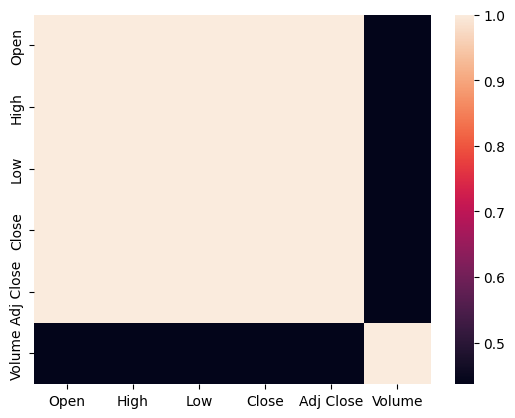

In [ ]:
#visualise the corrilation
sns.heatmap(gold_dataset.corr())

<Axes: >

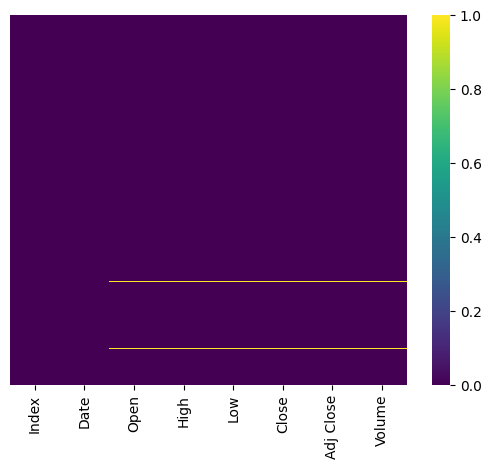

In [ ]:
%matplotlib inline
sns.heatmap(gold_dataset.isnull(), yticklabels=False, cmap="viridis")

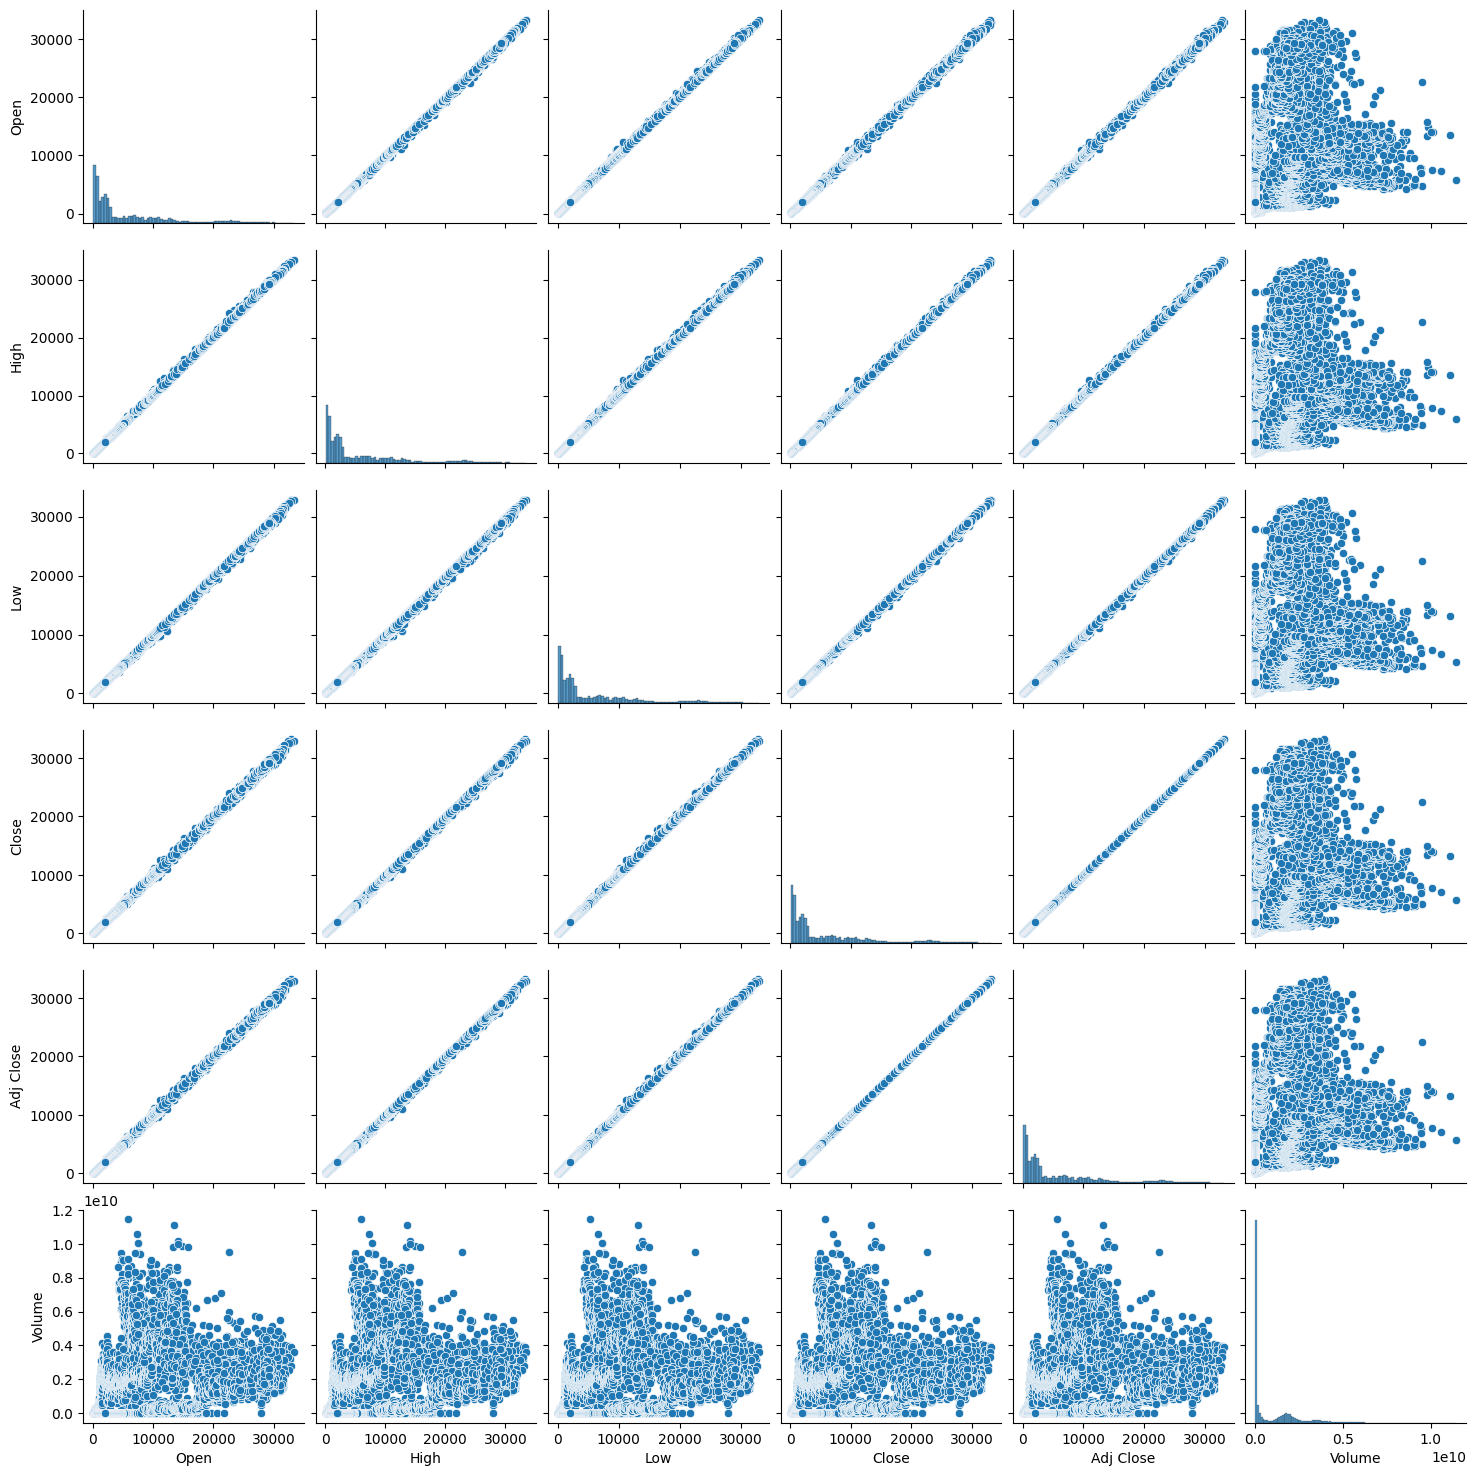

In [ ]:
#seaborn pairGrid
sns.pairplot(gold_dataset)

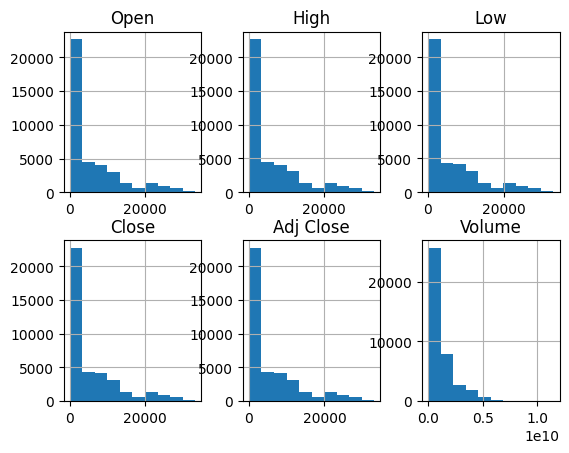

In [ ]:
gold_dataset.hist(layout = (2,3))
plt.show()

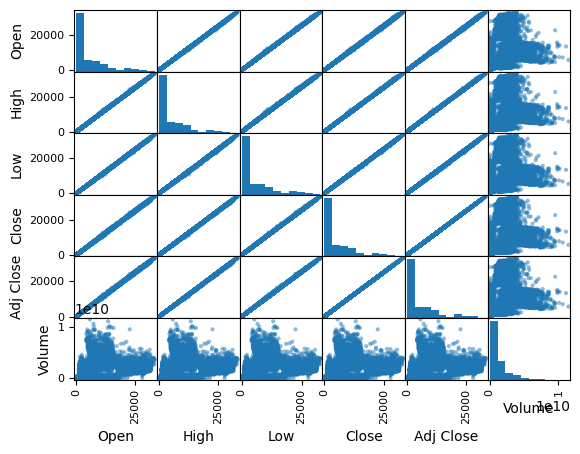

In [ ]:
import pandas
from pandas.plotting import scatter_matrix
scatter_matrix(gold_dataset)
plt.show()

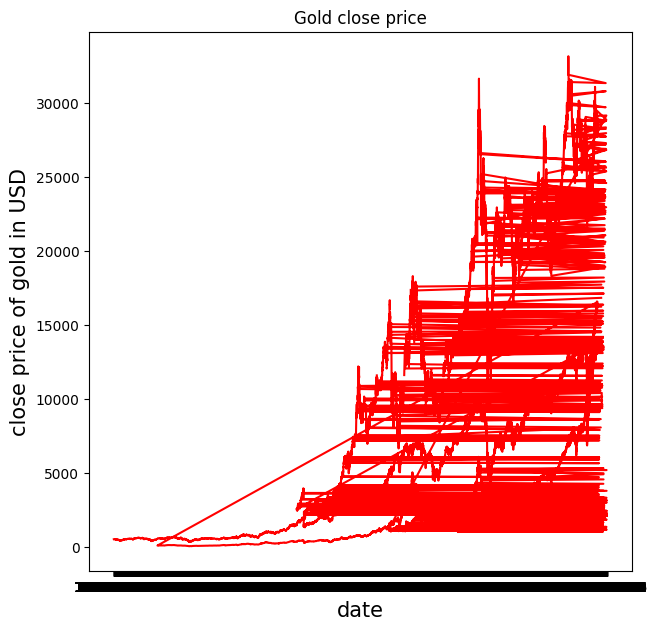

In [ ]:
fig = plt.figure(figsize = (7, 7))

plt.plot(gold_dataset["Date"], gold_dataset["Close"], color = "red")
plt.title("Gold close price")
plt.xlabel("date", fontsize = 15)
plt.ylabel("close price of gold in USD", fontsize = 15)
plt.show()

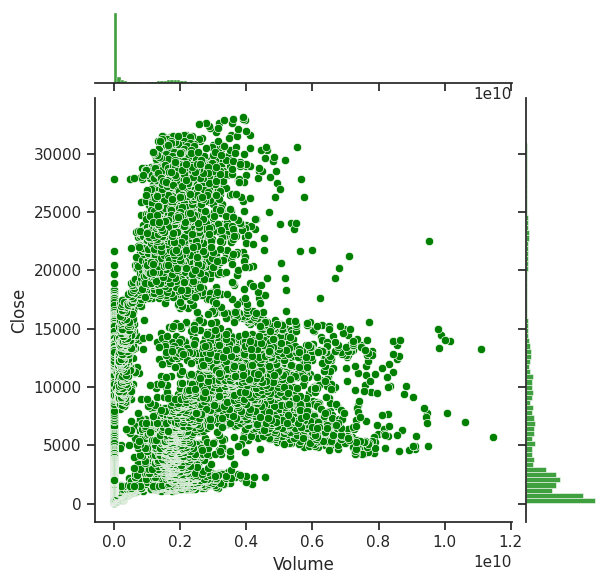

In [ ]:
sns.set(style="ticks",color_codes=True)
g = sns.jointplot(x="Volume", y="Close",data=gold_dataset,color="green" )


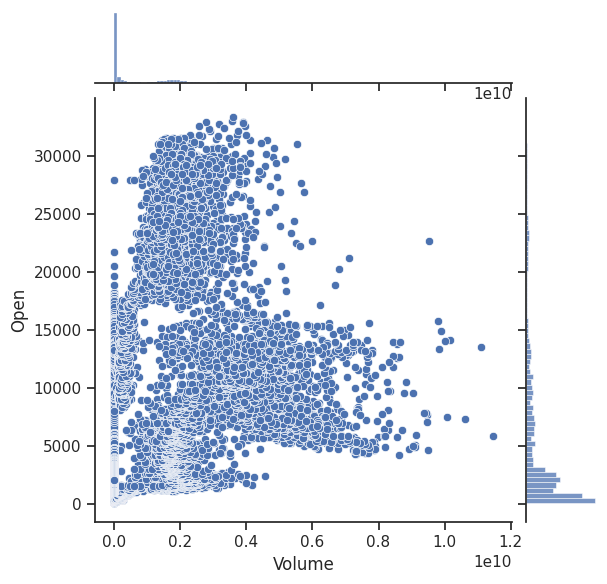

In [ ]:
g = sns.JointGrid(data=gold_dataset, x="Volume", y="Open")
g.plot(sns.scatterplot, sns.histplot)

In [ ]:
#training dataset
from sklearn.model_selection import train_test_split
X = gold_dataset[['Open', 'High','Volume','Close','Low']]
y = gold_dataset['Adj Close']


In [ ]:
y

0         528.690002
1         527.210022
2         527.840027
3         531.119995
4         532.070007
            ...     
39627    2026.358032
39628    2027.353027
39629    2028.037964
39630    2010.083008
39631            NaN
Name: Adj Close, Length: 39632, dtype: float64

In [ ]:
X

,Open,High,Volume,Close,Low
0,528.690002,528.690002,0.0,528.690002,528.690002
1,527.210022,527.210022,0.0,527.210022,527.210022
2,527.840027,527.840027,0.0,527.840027,527.840027
3,531.119995,531.119995,0.0,531.119995,531.119995
4,532.070007,532.070007,0.0,532.070007,532.070007
...,...,...,...,...,...
39627,2020.437988,2029.537964,74500.0,2026.358032,2016.577026
39628,2022.177979,2028.957031,79900.0,2027.353027,2007.350952
39629,2024.255981,2038.704956,74600.0,2028.037964,2021.484985
39630,2023.151978,2024.630981,74400.0,2010.083008,2008.451050


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
#testing algorithms
"""

Linear regression
Random forest regessor
Extra Tree Algorithm
Gradient Boosting Algorithm

"""
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor


In [ ]:
#linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

ValueError: ignored

In [ ]:
#check if there are empty cells in the set
gold_dataset.isnull().values.any()

True

In [ ]:
#check how many cells are empty
gold_dataset.isnull().sum()

Index          0
Date           0
Open         430
High         430
Low          431
Close        431
Adj Close    431
Volume       431
dtype: int64

In [ ]:
#how can I deal with the null values to make my training a sucess without dropping data
#drop the column, but from above I would drop all the sets,
#I have decided to use Mean and Median Fill
#gold_dataset['Adj Close'].fillna(0)
#gold_dataset['Adj Close'].bfill()

#most preffered from the article that I read
gold_dataset['High'].fillna(gold_dataset['High'].median(),inplace = True)
gold_dataset['Low'].fillna(gold_dataset['Low'].median(),inplace = True)

gold_dataset['Open'].fillna(gold_dataset['Open'].median(),inplace = True)
gold_dataset['Close'].fillna(gold_dataset['Close'].median(),inplace = True)

gold_dataset['Adj Close'].fillna(gold_dataset['Adj Close'].median(),inplace = True)
gold_dataset['Volume'].fillna(gold_dataset['Volume'].median(),inplace = True)

#lets proceed now to train our dataset
from sklearn.model_selection import train_test_split
X = gold_dataset[['Open', 'High','Low','Close','Volume']]
y = gold_dataset['Adj Close']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
#yeey we were able to create a model and train our model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
#RandomForest Regressor
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
#extraTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
extraTree = ExtraTreesRegressor()
extraTree.fit(X_train, y_train)

ExtraTreesRegressor()

In [ ]:
#GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)


GradientBoostingRegressor()

In [ ]:
#Prediction
#Linear regression Prediction
lr_prediction = lr.predict(X_test)
lr_prediction

array([ 233.35000667, 1747.93994167, 2755.30004967, ..., 2029.06701767,
        468.20001267,  433.50000057])

In [ ]:
#Random Forest Predictions
rfr_prediction = rfr.predict(X_test)
rfr_prediction

array([ 233.3396012 , 1747.93206072, 2755.02569093, ..., 2029.10941904,
        468.18679767,  433.4484077 ])

In [ ]:
#extra Tree Predictions
extraTree_prediction = extraTree.predict(X_test)
extraTree_prediction

array([ 233.355202  , 1747.95135267, 2755.30050294, ..., 2028.76121449,
        468.17989825,  433.55430764])

In [ ]:
#gradient boosting Predictions
gbr_prediction = gbr.predict(X_test)
gbr_prediction

array([ 233.99009309, 1690.44607041, 2729.93788611, ..., 1980.5295028 ,
        460.52221994,  454.07906098])

In [ ]:
#checking various prdeictions with metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("The mean absolute error metrix for Linear regression : " , mean_absolute_error(y_test, lr_prediction))
print("The mean absolute error metrix for Random forest regressor : " , mean_absolute_error(y_test, rfr_prediction))
print("The mean absolute error metrix for Extra Tress  : " , mean_absolute_error(y_test, extraTree_prediction))
print("The mean absolute error metrix for Gradient Boosting : " , mean_absolute_error(y_test, gbr_prediction))

The mean absolute error metrix for Linear regression :  8.037434509569327e-07
The mean absolute error metrix for Random forest regressor :  0.8251548852279104
The mean absolute error metrix for Extra Tress  :  1.3783512260169257
The mean absolute error metrix for Gradient Boosting :  30.231443701680256


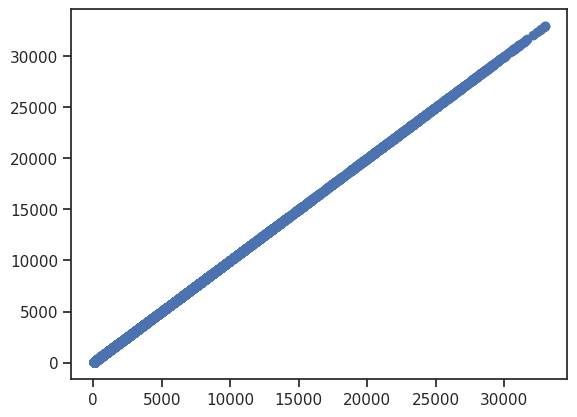

In [ ]:
#Linear Regression Plot
plt.scatter(lr_prediction, y_test)

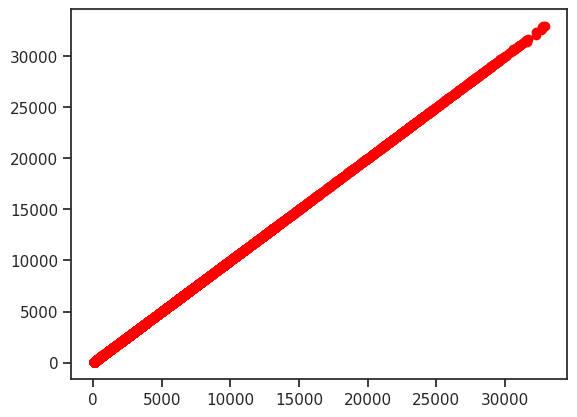

In [ ]:
plt.scatter(rfr_prediction, y_test,color="red")

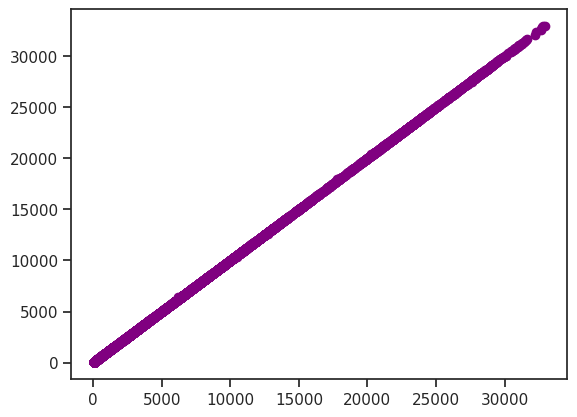

In [ ]:
plt.scatter(extraTree_prediction, y_test,color="purple")

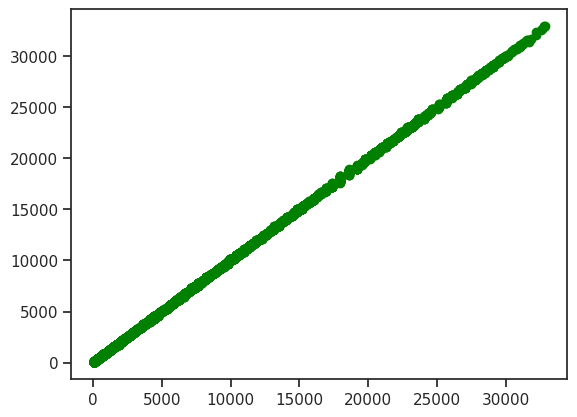

In [ ]:
plt.scatter(gbr_prediction, y_test,color="green")

In [ ]:
X_test

,Open,High,Low,Close,Volume
17355,233.350006,233.350006,233.350006,233.350006,0.000000e+00
5325,1747.939941,1747.939941,1747.939941,1747.939941,0.000000e+00
27354,2755.300049,2755.300049,2755.300049,2755.300049,0.000000e+00
27724,3512.000000,3554.000000,3512.000000,3552.000000,0.000000e+00
28279,6783.500000,6796.700195,6728.600098,6732.000000,0.000000e+00
...,...,...,...,...,...
13400,12601.209960,12641.070310,12555.830080,12632.580080,3.158170e+09
21261,4045.719971,4091.949951,4045.719971,4064.270020,1.656630e+09
39447,2000.817993,2029.927979,1997.057983,2029.067017,9.120000e+04
246,468.200012,468.200012,468.200012,468.200012,0.000000e+00


In [ ]:
# features open, high, low, close,Volume
features = np.array([[528.690002,	528.690002,528.690002	,	528.690002,0]])

lr_prediction = lr.predict(features)
lr_prediction

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([528.69000267])

In [ ]:
features = np.array([[550.570007,550.570007,550.570007,	550.570007,550.570007]])

rf_prediction = rfr.predict(features)
rf_prediction

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([550.570007])

In [ ]:
import joblib
joblib.dump(lr,"prediction_gold.joblib")

NameError: ignored